In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from fetch_jobs import get_data
import re

In [35]:
df = get_data("Business Analyst", '3')

Fetching page 1 to determine total pages...
Total pages: 32  |  Approx jobs: 1568 | Fetching: 3 pages


Fetching pages: 100%|██████████| 3/3 [00:03<00:00,  1.31s/page]

Dropping constant columns: ['standout', 'lantype', 'JobLang', 'OnlineJob', 'Salary.SalaryRange', 'Salary.SalaryType', 'Salary.IsNegotiable', 'Salary.HideSalary']


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162 entries, 0 to 161
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Jobid             162 non-null    object
 1   AdType            162 non-null    object
 2   jobTitle          162 non-null    object
 3   companyName       162 non-null    object
 4   JobTitleBng       162 non-null    object
 5   deadline          162 non-null    object
 6   deadlineDB        162 non-null    object
 7   publishDate       162 non-null    object
 8   eduRec            162 non-null    object
 9   degree_level      124 non-null    object
 10  major             71 non-null     object
 11  experience        162 non-null    object
 12  experience_level  137 non-null    object
 13  logo              162 non-null    object
 14  location          162 non-null    object
 15  division          162 non-null    object
 16  jobContext        43 non-null     object
 17  isEarlyAccess   

In [ ]:
df = df.drop(columns=['jobDescription','logoUrl','AdType','logo','logoUrl','jobContext','Cat_id','isEarlyAccess',], axis=1)

In [50]:
df = df[df['Salary.MaxSalary'] != 0 & (df['Salary.MinSalary'] != 0) & (df['Salary.MaxSalary'] != -1) & (df['Salary.MinSalary'] != -1)]

In [38]:
def keep_relevant_jobs(df, job_title):
    job_title = job_title.lower()
    relevant_rows = df['jobTitle'].str.lower().apply(lambda x: bool(re.findall(job_title, x, re.IGNORECASE)))
    return df[relevant_rows]

In [51]:
workplace_mapping = {
    '': 'Hybrid',
    'Home': 'Remote',
    'Office': 'On-site',
}

df['WorkPlace'] = df['WorkPlace'].str.strip().replace(workplace_mapping)

In [40]:
df['degree_level'] = df['degree_level'].str.split(',').apply(lambda x: [i.strip() for i in x] if isinstance(x, list) else x)
df['major'] = df['major'].str.split(',').apply(lambda x: [i.strip() for i in x] if isinstance(x, list) else x)


df_exploded = df.explode('degree_level').explode('major')

major_mapping = {
    'Finance & Banking': 'Finance',
    'Finance and Banking': 'Finance',
    'Accounting & Information System': 'Accounting',
    'Accounting and Information System': 'Accounting',
    # etc.
}
df_exploded['major'] = df_exploded['major'].replace(major_mapping)

In [52]:
df_exploded.head()

,Jobid,jobTitle,companyName,JobTitleBng,deadline,deadlineDB,publishDate,eduRec,degree_level,major,experience,experience_level,location,division,JobType,Vacancies,WorkPlace,Salary.MinSalary,Salary.MaxSalary
2,1491274,Business Analyst,Envobyte Ltd.,Business Analyst,2026-06-23,2026-06-23,2026-05-24,Bachelor of Science (BSc),BSc,<NA>,At least 3 years,Mid,Khulna,Khulna,FullTime,1,On-site,20000,-1
9,1487108,Analyst - Data Solutions,SEBPO,Analyst - Data Solutions,2026-06-10,2026-06-10,2026-05-11,Bachelor/Honors,Bachelor,<NA>,NA,<NA>,Mohakhali,Dhaka,FullTime,30,On-site,16000,18000
9,1487108,Analyst - Data Solutions,SEBPO,Analyst - Data Solutions,2026-06-10,2026-06-10,2026-05-11,Bachelor/Honors,Honours,<NA>,NA,<NA>,Mohakhali,Dhaka,FullTime,30,On-site,16000,18000
10,1492437,সিনিয়র অফিসার / Senior Officer,UCB Business Limited,সিনিয়র অফিসার / Senior Officer,2026-07-02,2026-07-02,2026-06-02,,<NA>,<NA>,NA,<NA>,"Pabna, Ataikula, Atgharia, Bera, Bhangura, Cha...",Multiple,FullTime,35,On-site,32000,37000
11,1492421,ফ্রন্ট ডেস্ক অ্যাকাউন্ট অফিসার,UCB Business Limited,ফ্রন্ট ডেস্ক অ্যাকাউন্ট অফিসার,2026-07-02,2026-07-02,2026-06-02,,<NA>,<NA>,NA,<NA>,Pabna Sadar,Rajshahi,FullTime,5,On-site,12000,24000


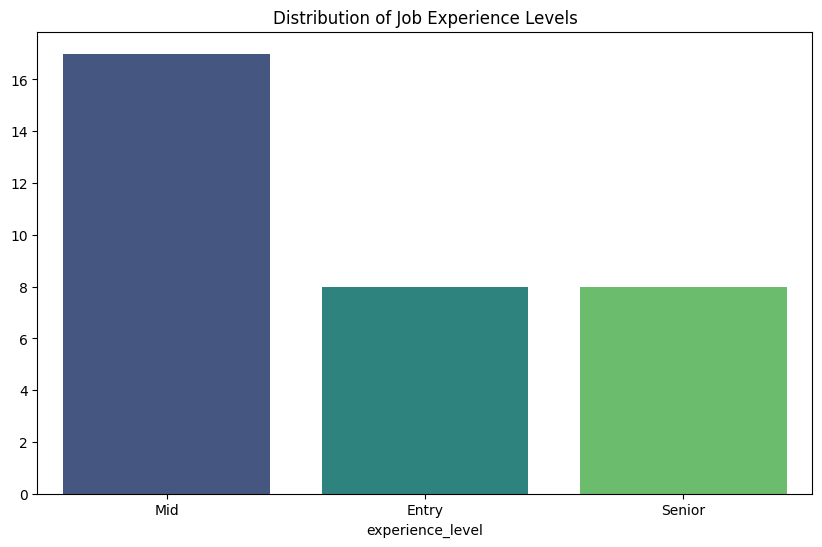

In [43]:
job_experience_counts = df['experience_level'].value_counts()
plt.figure(figsize=(10, 6))
plt.title('Distribution of Job Experience Levels')
sns.barplot(x=job_experience_counts.index, y=job_experience_counts.values, hue=job_experience_counts.index,palette='viridis')
plt.show()

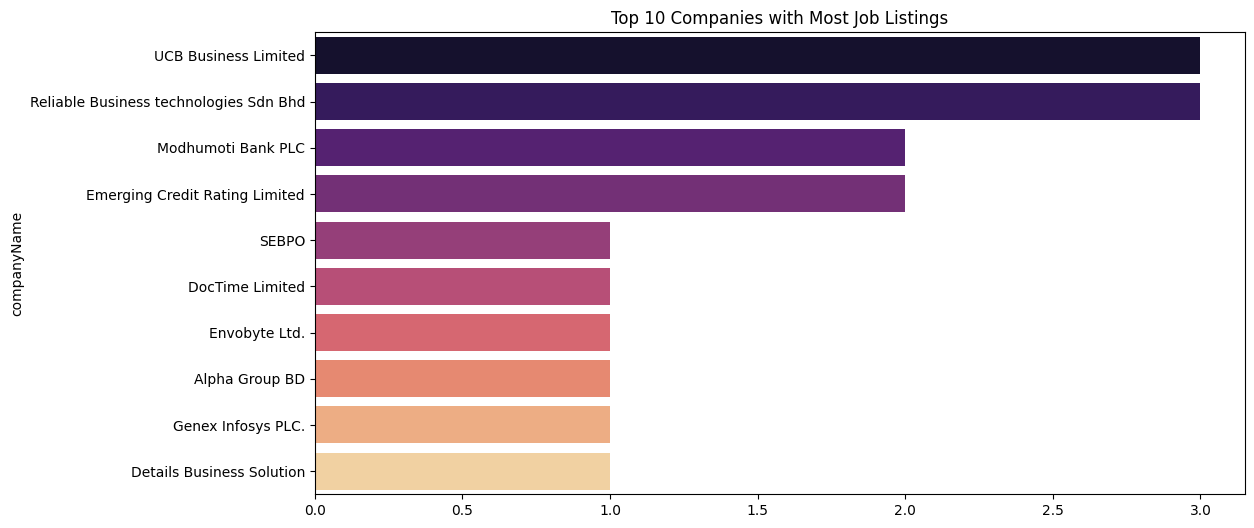

In [44]:
company_counts = df['companyName'].value_counts().head(10)
plt.figure(figsize=(12, 6))
plt.title('Top 10 Companies with Most Job Listings')
sns.barplot(y=company_counts.index, x=company_counts.values, hue=company_counts.index,palette='magma')
plt.show()

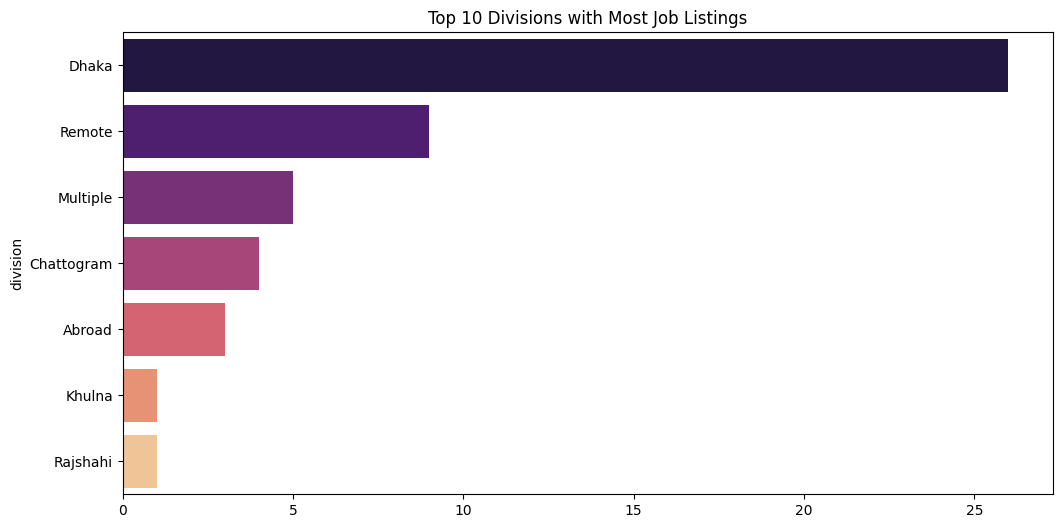

In [45]:
division_counts = df['division'].value_counts().head(10)

plt.figure(figsize=(12, 6))
plt.title('Top 10 Divisions with Most Job Listings')
sns.barplot(y=division_counts.index, x=division_counts.values, hue=division_counts.index,palette='magma')
plt.show()

<Axes: title={'center': 'Top 10 Degree Levels with Most Job Listings'}, ylabel='degree_level'>

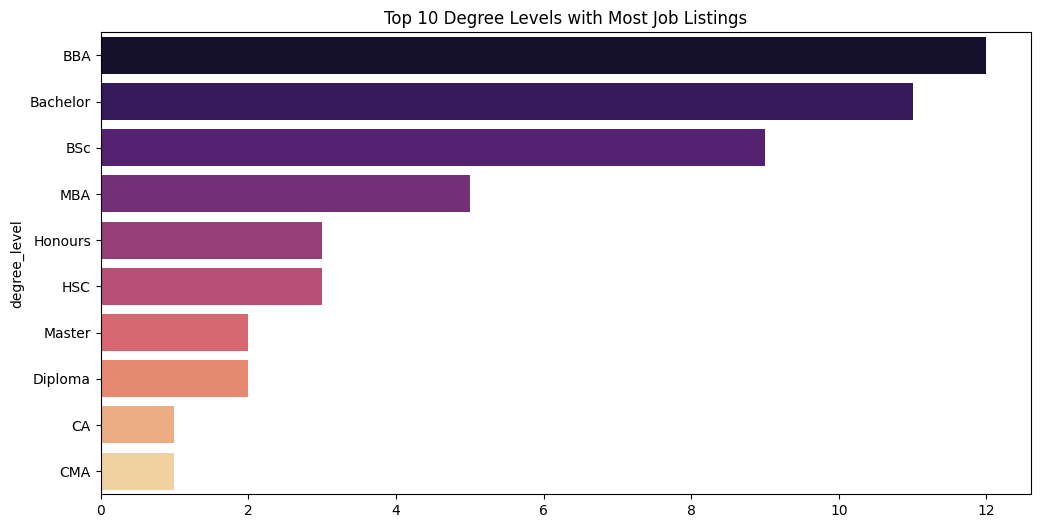

In [46]:
degree_level_counts = df_exploded['degree_level'].value_counts().head(10)
plt.figure(figsize=(12, 6))
plt.title('Top 10 Degree Levels with Most Job Listings')
sns.barplot(y=degree_level_counts.index, x=degree_level_counts.values, hue=degree_level_counts.index,palette='magma')

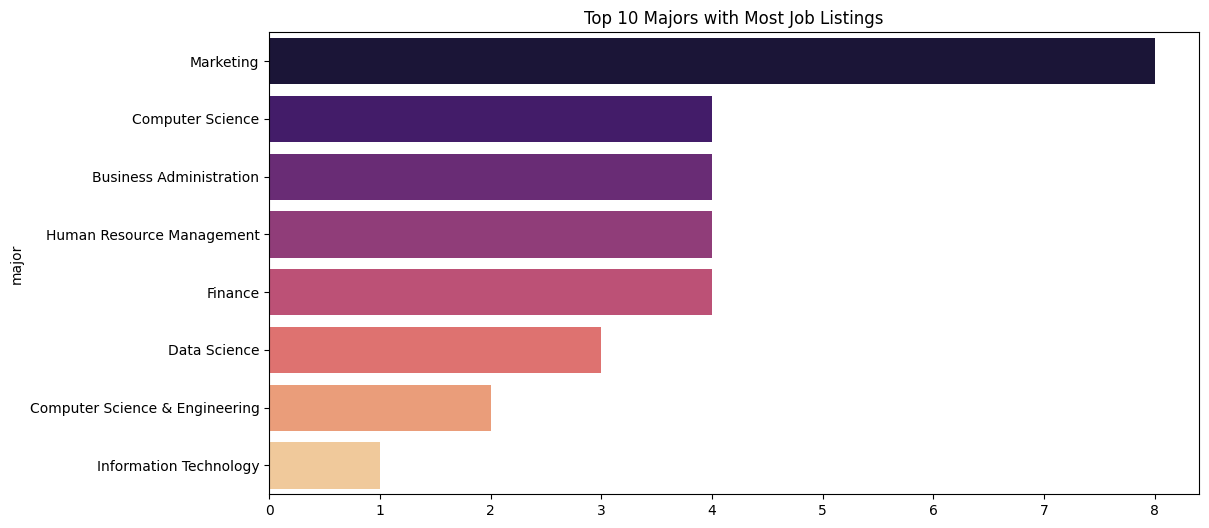

In [47]:
major_counts = df_exploded['major'].value_counts().head(10)
plt.figure(figsize=(12, 6))
plt.title('Top 10 Majors with Most Job Listings')
sns.barplot(y=major_counts.index, x=major_counts.values, hue=major_counts.index,palette='magma')
plt.show()

Text(0.5, 1.0, 'Distribution of Workplace Types')

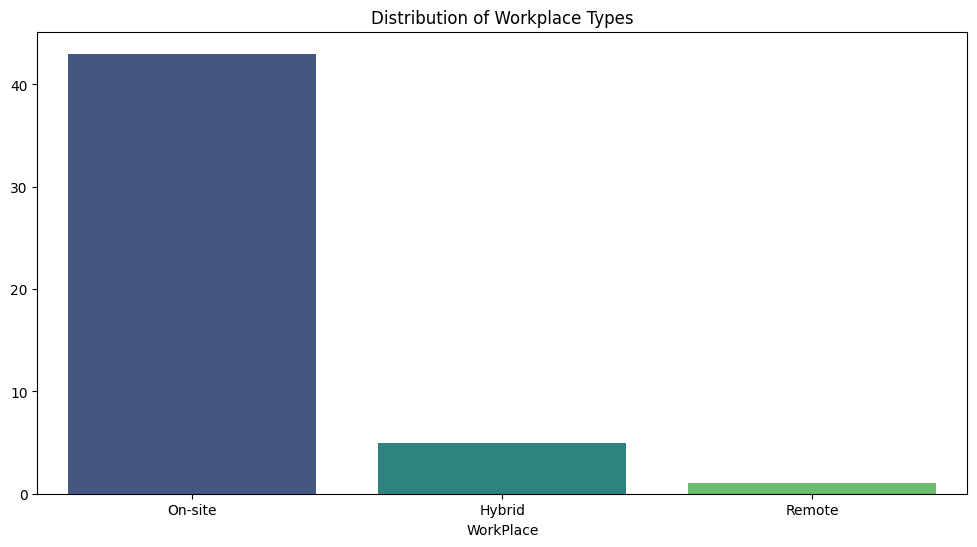

In [58]:
workplace_counts = df['WorkPlace'].value_counts()
plt.figure(figsize=(12, 6))
sns.barplot(x=workplace_counts.index, y=workplace_counts.values, hue=workplace_counts.index,palette='viridis')
plt.title('Distribution of Workplace Types')

Text(0.5, 1.0, 'Distribution of Job Types')

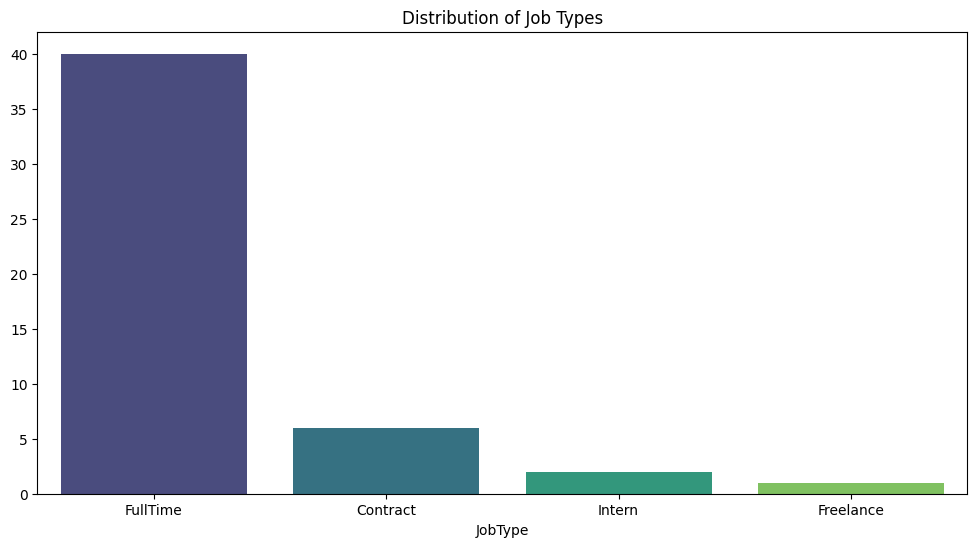

In [60]:
job_type_counts = df['JobType'].value_counts()
plt.figure(figsize=(12, 6))
sns.barplot(x=job_type_counts.index, y=job_type_counts.values, hue=job_type_counts.index,palette='viridis')
plt.title('Distribution of Job Types')